<a href="https://colab.research.google.com/github/pramodgurung10/AI-ML/blob/main/Worksheet9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))


Num GPUs Available: 1


In [2]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0


##System Design

Data Pre processing and Analysis


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# Load the dataset
data = pd.read_csv("/content/drive/MyDrive/ConceptAI/trum_tweet_sentiment_analysis.csv", encoding="ISO-8859-1")


In [7]:
# Preprocessing function
def preprocess_text(text):
    text = text.lower() # Lowercase
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # Remove URLs
    text = re.sub(r'\@\w+|#', '', text) # Remove mentions/hashtags
    text = re.sub(r'[^\w\s]', '', text) # Remove punctuation
    text = re.sub(r'\d+', '', text) # Remove numbers
    # Remove stopwords and lemmatize
    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

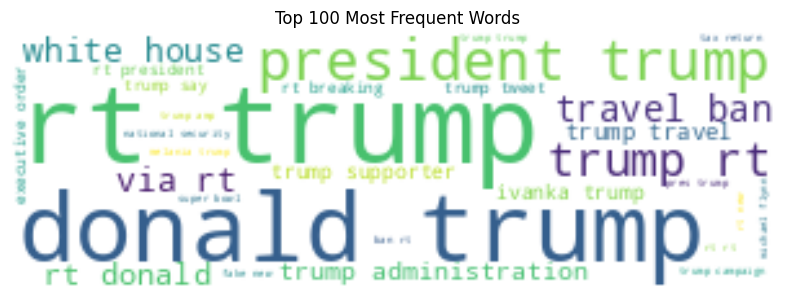

In [8]:
from wordcloud import WordCloud

# Apply preprocessing to create the 'cleaned_text' column
data['cleaned_text'] = data['text'].apply(preprocess_text)

# --- Visualization: Word Cloud (Top 100 Words) ---
all_words = ' '.join(data['cleaned_text'])
# Generate WordCloud with only top 100 words
wordcloud = WordCloud(
width=300,
height=100,
background_color='white',
max_words=100 # Limit to top 100 words
).generate(all_words)
# Plot settings
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Top 100 Most Frequent Words')
plt.show()

##Tokenization and Padding:

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encode the 'Sentiment' column into numerical labels
label_encoder = LabelEncoder()
data['sentiment_encoded'] = label_encoder.fit_transform(data['Sentiment'])

# Split data into training + validation and test sets FIRST (before tokenization)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    data['cleaned_text'],       # Features (text)
    data['sentiment_encoded'],  # Labels
    test_size=0.2,
    random_state=42
)

# Now, split the X_train_full and y_train_full into actual training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.15, # Use 15% of the training data for validation (15% of 80% = 12% of total)
    random_state=42
)

In [10]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Initialize the tokenizer
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")  # 'num_words' limits vocab size; 'oov_token' handles unknown words
tokenizer.fit_on_texts(data['cleaned_text'])  # Learn word index from the entire cleaned text data

# Convert text to sequences of integers
# The following 'texts' variable and print statements are for demonstration and can be removed or kept as is.
texts = [
    "I love this product!",
    "Worst purchase ever.",
    "Happy with the experience.",
    "Not great, not terrible.",
    "Absolutely fantastic!"
]
sequences = tokenizer.texts_to_sequences(texts);

# Print results (optional, for demonstration with small sample)
print("Word Index (sample vocab):")
print({k: tokenizer.word_index[k] for k in list(tokenizer.word_index)[:10]} ) # Print first 10 for brevity
print("Sequences (sample texts):")
print(sequences)

# Optional: pad sequences to ensure equal length (for sample texts)
padded = pad_sequences(sequences, padding='post')
print("Padded Sequences (sample texts):")
print(padded)

Word Index (sample vocab):
{'<OOV>': 1, 'trump': 2, 'rt': 3, 'donald': 4, 'president': 5, 'u': 6, 'amp': 7, 'ban': 8, 'say': 9, 'flynn': 10}
Sequences (sample texts):
[[1, 155, 1, 530], [923, 7484, 180], [861, 1, 7225, 2359], [1, 121, 1, 1738], [1110, 3923]]
Padded Sequences (sample texts):
[[   1  155    1  530]
 [ 923 7484  180    0]
 [ 861    1 7225 2359]
 [   1  121    1 1738]
 [1110 3923    0    0]]


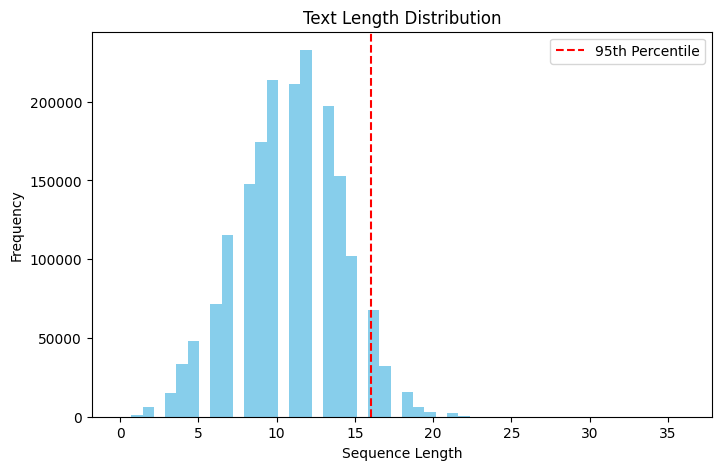

In [11]:
# Tokenize X_train and X_test
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)
X_val_seq = tokenizer.texts_to_sequences(X_val)

# Calculate max_len using percentile
seq_lengths = [len(seq) for seq in X_train_seq]
max_len = int(np.percentile(seq_lengths, 95))  # Adjust percentile as needed

# Pad sequences
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=max_len, padding='post', truncating='post')

# Convert all text to sequences (this part is for plotting full distribution, already correct)
X_seq = tokenizer.texts_to_sequences(data['cleaned_text'])
seq_lengths = [len(seq) for seq in X_seq]

# Plot distribution of sequence lengths
plt.figure(figsize=(8, 5))
plt.hist(seq_lengths, bins=50, color='skyblue')
plt.title('Text Length Distribution')
plt.xlabel('Sequence Length')
plt.ylabel('Frequency')
plt.axvline(np.percentile(seq_lengths, 95), color='red', linestyle='dashed', label='95th Percentile')
plt.legend()
plt.show()

5 Tasks:
1. Data Preprocessing & Cleaning

    • Load the dataset using Pandas.

    • Clean the text by:– Lowercasing– Removing URLs, mentions (@user), hashtags (#), numbers, and special characters– Handling contractions (e.g., ”don’t” → ”do not”)
    – Removing stopwords and lemmatizing words

    • Visualize the cleaned data (e.g., word cloud, most frequent words).

In [12]:
!pip install contractions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 14.8 MB/s eta 0:00:00


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [14]:
# Load the dataset
data = pd.read_csv("/content/drive/MyDrive/ConceptAI/trum_tweet_sentiment_analysis.csv", encoding="ISO-8859-1")


In [15]:
print(f"Total rows: {len(data)}")
print(f"Columns   : {list(data.columns)}")

Total rows: 1850123
Columns   : ['text', 'Sentiment']


In [16]:
data.sample(6)

,text,Sentiment
574633,RT @nytopinion: Like a teenager who didnÂt do...,1
583548,Fucking Alex...shut up about Trump....NOBODY C...,0
11357,U.S. appeals court denies reinstatement of Tru...,0
1089276,RT @weaselzippers: Trump Could Remake The Fede...,0
749363,RT @Impeach_D_Trump: The 3 judges on the 9th c...,0
19353,At times recently I've cautioned against Trump...,1


In [17]:
def preprocess_text(text):
    text = str(text).lower()
    text = contractions.fix(text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text,
                  flags=re.MULTILINE)
    text = re.sub(r'\@\w+|\#', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    # Remove stopwords and lemmatize
    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()
    tokens     = text.split()
    tokens     = [lemmatizer.lemmatize(word)
                  for word in tokens
                  if word not in stop_words and len(word) > 1]
    return ' '.join(tokens)

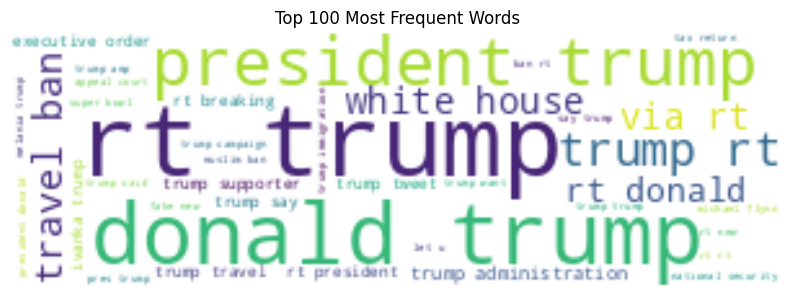

In [18]:
import contractions
from wordcloud import WordCloud

# Apply preprocessing to create the 'cleaned_text' column
data['cleaned_text'] = data['text'].apply(preprocess_text)

# --- Visualization: Word Cloud (Top 100 Words) ---
all_words = ' '.join(data['cleaned_text'])
# Generate WordCloud with only top 100 words
wordcloud = WordCloud(
width=300,
height=100,
background_color='white',
max_words=100 # Limit to top 100 words
).generate(all_words)
# Plot settings
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Top 100 Most Frequent Words')
plt.show()

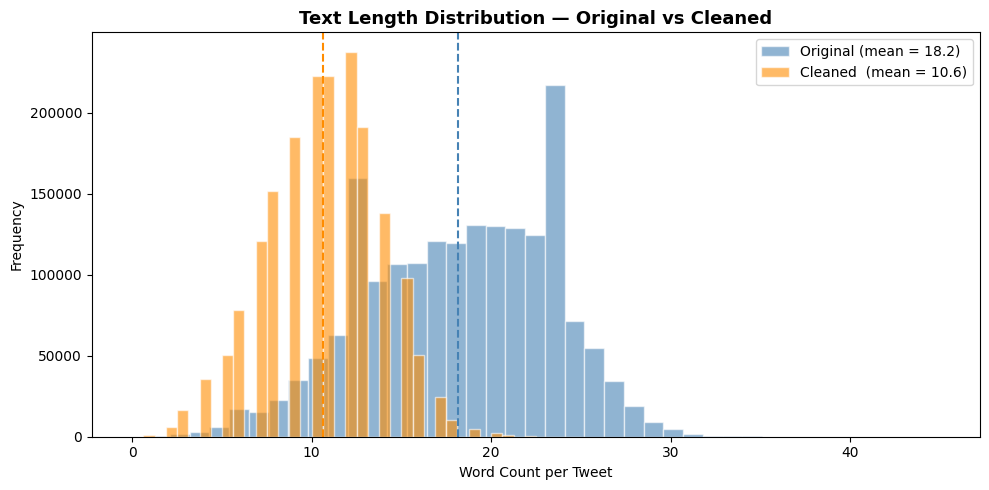

In [19]:
orig_lengths  = data['text'].str.split().str.len()
clean_lengths = data['cleaned_text'].str.split().str.len()

plt.figure(figsize=(10, 5))
plt.hist(orig_lengths,  bins=40, alpha=0.6,
         label=f'Original (mean = {orig_lengths.mean():.1f})',
         color='steelblue', edgecolor='white')
plt.hist(clean_lengths, bins=40, alpha=0.6,
         label=f'Cleaned  (mean = {clean_lengths.mean():.1f})',
         color='darkorange', edgecolor='white')
plt.axvline(orig_lengths.mean(),  color='steelblue',
            linestyle='--', linewidth=1.5)
plt.axvline(clean_lengths.mean(), color='darkorange',
            linestyle='--', linewidth=1.5)
plt.title('Text Length Distribution — Original vs Cleaned',
          fontsize=13, fontweight='bold')
plt.xlabel('Word Count per Tweet')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

2. Tokenization & Padding

    • Split the dataset into 80% training and 20% testing using train

    • Use Keras Tokenizer to convert text into sequences.
    test
    split.
    
    • Apply padding to ensure uniform sequence lengths (use percentile-based padding)

In [20]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    data['cleaned_text'],          # Features (cleaned text)
    data['Sentiment'],             # Labels
    test_size=0.2,                 # 80% train, 20% test
    random_state=42,
    stratify=data['Sentiment']     # Keep class balance in both splits
)

print(f"Dataset split:")
print(f"  Training : {len(X_train)} samples ({len(X_train)/len(data)*100:.0f}%)")
print(f"  Testing  : {len(X_test)}  samples ({len(X_test)/len(data)*100:.0f}%)")
print(f"\n  Train class distribution:\n{y_train.value_counts()}")
print(f"\n  Test class distribution:\n{y_test.value_counts()}")

Dataset split:
  Training : 1480098 samples (80%)
  Testing  : 370025  samples (20%)

  Train class distribution:
Sentiment
0    995369
1    484729
Name: count, dtype: int64

  Test class distribution:
Sentiment
0    248842
1    121183
Name: count, dtype: int64


In [22]:
VOCAB_SIZE = 10000   # Limit vocabulary to top 10,000 words

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)   # Vocabulary based ONLY on training data

print(f"Vocabulary size (unique words in training): {len(tokenizer.word_index)}")
print(f"\nTop 10 tokens in vocabulary:")
top_10 = list(tokenizer.word_index.items())[:10]
for word, idx in top_10:
    print(f"  '{word}' → {idx}")

Vocabulary size (unique words in training): 155362

Top 10 tokens in vocabulary:
  '<OOV>' → 1
  'trump' → 2
  'rt' → 3
  'donald' → 4
  'president' → 5
  'amp' → 6
  'ban' → 7
  'u' → 8
  'say' → 9
  'flynn' → 10


In [23]:
#convert text to sequneces
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

print("Sample tokenized sequence (first training tweet):")
print(f"  Text    : {X_train.iloc[0]}")
print(f"  Sequence: {X_train_seq[0]}")

Sample tokenized sequence (first training tweet):
  Text    : rt trump power handshake ranked weirdness shinzo abe romney bill rancic gorsuch
  Sequence: [3, 2, 137, 401, 1, 1, 724, 258, 5535, 231, 1, 457]


In [24]:
seq_lengths = [len(seq) for seq in X_train_seq]

print(f"Sequence length stats (training set):")
print(f"  Min    : {min(seq_lengths)}")
print(f"  Max    : {max(seq_lengths)}")
print(f"  Mean   : {np.mean(seq_lengths):.1f}")
print(f"  Median : {np.median(seq_lengths):.1f}")

max_len = int(np.percentile(seq_lengths, 95))
print(f"\n  95th percentile → max_len = {max_len}")

Sequence length stats (training set):
  Min    : 0
  Max    : 25
  Mean   : 10.6
  Median : 11.0

  95th percentile → max_len = 16


In [25]:
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len,
                             padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=max_len,
                             padding='post', truncating='post')

print(f"Padded shapes:")
print(f"  X_train_pad : {X_train_pad.shape}")
print(f"  X_test_pad  : {X_test_pad.shape}")
print(f"\nSample padded sequence (first training tweet):")
print(f"  {X_train_pad[0]}")

Padded shapes:
  X_train_pad : (1480098, 16)
  X_test_pad  : (370025, 16)

Sample padded sequence (first training tweet):
  [   3    2  137  401    1    1  724  258 5535  231    1  457    0    0
    0    0]


In [26]:
y_train_arr = np.array(y_train)
y_test_arr  = np.array(y_test)

print(f"Label shapes:")
print(f"  y_train : {y_train_arr.shape}")
print(f"  y_test  : {y_test_arr.shape}")

Label shapes:
  y_train : (1480098,)
  y_test  : (370025,)


3. Model Building
Implement two models:
    1. Simple RNN
    2. LSTM

    Each model should include:

    • Embedding Layer (input

    • Recurrent Layer (SimpleRNN or LSTM with 64 units)
    dim=vocab
    size, output
    dim=128)
    
    • Dense Layer (sigmoid activation for binary classification)

In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout

In [28]:
VOCAB_SIZE     = 10000
EMBEDDING_DIM  = 128
RNN_UNITS      = 64
MAX_LEN        = max_len

In [29]:
rnn_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE,       # Size of vocabulary
              output_dim=EMBEDDING_DIM,   # Dense vector size per word
              input_length=MAX_LEN),      # Length of input sequences
    SimpleRNN(units=RNN_UNITS,            # 64 RNN units
              return_sequences=False),    # Many-to-One (last hidden state only)
    Dropout(0.3),                         # Prevent overfitting
    Dense(1, activation='sigmoid')        # Binary classification output
])

# Compile
rnn_model.compile(
    loss='binary_crossentropy',           # Binary classification
    optimizer='adam',
    metrics=['accuracy']
)

print("Simple RNN Model Summary:")
rnn_model.build(input_shape=(None, MAX_LEN))
rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Simple RNN Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 16, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,292,417 (4.93 MB)

 Trainable params: 1,292,417 (4.93 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
lstm_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE,       # Size of vocabulary
              output_dim=EMBEDDING_DIM,   # Dense vector size per word
              input_length=MAX_LEN),      # Length of input sequences
    LSTM(units=RNN_UNITS,                 # 64 LSTM units
         return_sequences=False),         # Many-to-One (last hidden state only)
    Dropout(0.3),                         # Prevent overfitting
    Dense(1, activation='sigmoid')        # Binary classification output
])

# Compile
lstm_model.compile(
    loss='binary_crossentropy',           # Binary classification
    optimizer='adam',
    metrics=['accuracy']
)

print("LSTM Model Summary:")
lstm_model.build(input_shape=(None, MAX_LEN))
lstm_model.summary()

LSTM Model Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 16, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,329,473 (5.07 MB)

 Trainable params: 1,329,473 (5.07 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
rnn_params  = rnn_model.count_params()
lstm_params = lstm_model.count_params()

print(f"{'Model':<15} {'Total Parameters':>20}")
print("-" * 37)
print(f"{'Simple RNN':<15} {rnn_params:>20,}")
print(f"{'LSTM':<15} {lstm_params:>20,}")
print(f"\nLSTM has {lstm_params // rnn_params}x more parameters than Simple RNN")
print("(due to 4 gates: forget, input, cell, output)")

Model               Total Parameters
-------------------------------------
Simple RNN                 1,292,417
LSTM                       1,329,473

LSTM has 1x more parameters than Simple RNN
(due to 4 gates: forget, input, cell, output)


4. Training & Evaluation

    • Compile models with:
    – Loss: binary
    crossentropy

    – Optimizer: adam

    – Metrics: accuracy
    
    • Train for 10 epochs with early stopping.

    • Evaluate using

In [32]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np

In [33]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,                    # Stop after 3 epochs of no improvement
    restore_best_weights=True,     # Roll back to best epoch weights
    verbose=1
)

# Save the best model during training
checkpoint_rnn = ModelCheckpoint(
    'best_rnn_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

checkpoint_lstm = ModelCheckpoint(
    'best_lstm_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

In [34]:
print("Training Simple RNN Model")

rnn_history = rnn_model.fit(
    X_train_pad, y_train_arr,
    epochs=10,
    batch_size=64,
    validation_data=(X_test_pad, y_test_arr),
    callbacks=[early_stop, checkpoint_rnn],
    verbose=1
)

Training Simple RNN Model
Epoch 1/10
23127/23127 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9149 - loss: 0.2148
Epoch 1: val_accuracy improved from None to 0.95397, saving model to best_rnn_model.h5



Epoch 1: finished saving model to best_rnn_model.h5
23127/23127 ━━━━━━━━━━━━━━━━━━━━ 117s 5ms/step - accuracy: 0.9372 - loss: 0.1688 - val_accuracy: 0.9540 - val_loss: 0.1290
Epoch 2/10
23122/23127 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9591 - loss: 0.1173
Epoch 2: val_accuracy improved from 0.95397 to 0.95914, saving model to best_rnn_model.h5



Epoch 2: finished saving model to best_rnn_model.h5
23127/23127 ━━━━━━━━━━━━━━━━━━━━ 112s 5ms/step - accuracy: 0.9594 - loss: 0.1173 - val_accuracy: 0.9591 - val_loss: 0.1182
Epoch 3/10
23124/23127 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9664 - loss: 0.0993
Epoch 3: val_accuracy improved from 0.95914 to 0.96018, saving model to best_rnn_model.h5



Epoch 3: finished saving model to best_rnn_model.h5
23127/23127 ━━━━━━━━━━━━━━━━━━━━ 110s 5ms/step - accuracy: 0.9654 - loss: 0.1020 - val_accuracy: 0.9602 - val_loss: 0.1154
Epoch 4/10
23126/23127 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9694 - loss: 0.0912
Epoch 4: val_accuracy improved from 0.96018 to 0.96067, saving model to best_rnn_model.h5



Epoch 4: finished saving model to best_rnn_model.h5
23127/23127 ━━━━━━━━━━━━━━━━━━━━ 112s 5ms/step - accuracy: 0.9682 - loss: 0.0941 - val_accuracy: 0.9607 - val_loss: 0.1149
Epoch 5/10
23118/23127 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9715 - loss: 0.0855
Epoch 5: val_accuracy improved from 0.96067 to 0.96171, saving model to best_rnn_model.h5



Epoch 5: finished saving model to best_rnn_model.h5
23127/23127 ━━━━━━━━━━━━━━━━━━━━ 110s 5ms/step - accuracy: 0.9700 - loss: 0.0894 - val_accuracy: 0.9617 - val_loss: 0.1137
Epoch 6/10
23120/23127 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9722 - loss: 0.0831
Epoch 6: val_accuracy improved from 0.96171 to 0.96199, saving model to best_rnn_model.h5



Epoch 6: finished saving model to best_rnn_model.h5
23127/23127 ━━━━━━━━━━━━━━━━━━━━ 109s 5ms/step - accuracy: 0.9708 - loss: 0.0871 - val_accuracy: 0.9620 - val_loss: 0.1133
Epoch 7/10
23126/23127 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9726 - loss: 0.0822
Epoch 7: val_accuracy did not improve from 0.96199
23127/23127 ━━━━━━━━━━━━━━━━━━━━ 110s 5ms/step - accuracy: 0.9713 - loss: 0.0862 - val_accuracy: 0.9607 - val_loss: 0.1152
Epoch 8/10
23119/23127 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9725 - loss: 0.0824
Epoch 8: val_accuracy did not improve from 0.96199
23127/23127 ━━━━━━━━━━━━━━━━━━━━ 110s 5ms/step - accuracy: 0.9713 - loss: 0.0859 - val_accuracy: 0.9613 - val_loss: 0.1163
Epoch 9/10
23117/23127 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9722 - loss: 0.0836
Epoch 9: val_accuracy did not improve from 0.96199
23127/23127 ━━━━━━━━━━━━━━━━━━━━ 110s 5ms/step - accuracy: 0.9709 - loss: 0.0871 - val_accuracy: 0.9604 - val_loss: 0.1176
Epoch 9: early stopping
Restorin

In [35]:
print("Training LSTM Model")

# Reset early stopping for LSTM
early_stop_lstm = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

lstm_history = lstm_model.fit(
    X_train_pad, y_train_arr,
    epochs=10,
    batch_size=64,
    validation_data=(X_test_pad, y_test_arr),
    callbacks=[early_stop_lstm, checkpoint_lstm],
    verbose=1
)

Training LSTM Model
Epoch 1/10
23120/23127 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9221 - loss: 0.1968
Epoch 1: val_accuracy improved from None to 0.96104, saving model to best_lstm_model.h5



Epoch 1: finished saving model to best_lstm_model.h5
23127/23127 ━━━━━━━━━━━━━━━━━━━━ 176s 7ms/step - accuracy: 0.9449 - loss: 0.1484 - val_accuracy: 0.9610 - val_loss: 0.1109
Epoch 2/10
23121/23127 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9661 - loss: 0.0972
Epoch 2: val_accuracy improved from 0.96104 to 0.96739, saving model to best_lstm_model.h5



Epoch 2: finished saving model to best_lstm_model.h5
23127/23127 ━━━━━━━━━━━━━━━━━━━━ 170s 7ms/step - accuracy: 0.9671 - loss: 0.0948 - val_accuracy: 0.9674 - val_loss: 0.0947
Epoch 3/10
23123/23127 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9742 - loss: 0.0751
Epoch 3: val_accuracy improved from 0.96739 to 0.97035, saving model to best_lstm_model.h5



Epoch 3: finished saving model to best_lstm_model.h5
23127/23127 ━━━━━━━━━━━━━━━━━━━━ 200s 7ms/step - accuracy: 0.9739 - loss: 0.0759 - val_accuracy: 0.9704 - val_loss: 0.0884
Epoch 4/10
23124/23127 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9789 - loss: 0.0615
Epoch 4: val_accuracy improved from 0.97035 to 0.97053, saving model to best_lstm_model.h5



Epoch 4: finished saving model to best_lstm_model.h5
23127/23127 ━━━━━━━━━━━━━━━━━━━━ 203s 7ms/step - accuracy: 0.9782 - loss: 0.0636 - val_accuracy: 0.9705 - val_loss: 0.0864
Epoch 5/10
23123/23127 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9824 - loss: 0.0514
Epoch 5: val_accuracy improved from 0.97053 to 0.97120, saving model to best_lstm_model.h5



Epoch 5: finished saving model to best_lstm_model.h5
23127/23127 ━━━━━━━━━━━━━━━━━━━━ 168s 7ms/step - accuracy: 0.9816 - loss: 0.0540 - val_accuracy: 0.9712 - val_loss: 0.0874
Epoch 6/10
23125/23127 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9851 - loss: 0.0441
Epoch 6: val_accuracy improved from 0.97120 to 0.97125, saving model to best_lstm_model.h5



Epoch 6: finished saving model to best_lstm_model.h5
23127/23127 ━━━━━━━━━━━━━━━━━━━━ 171s 7ms/step - accuracy: 0.9842 - loss: 0.0465 - val_accuracy: 0.9713 - val_loss: 0.0904
Epoch 7/10
23123/23127 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9874 - loss: 0.0372
Epoch 7: val_accuracy improved from 0.97125 to 0.97151, saving model to best_lstm_model.h5



Epoch 7: finished saving model to best_lstm_model.h5
23127/23127 ━━━━━━━━━━━━━━━━━━━━ 169s 7ms/step - accuracy: 0.9863 - loss: 0.0402 - val_accuracy: 0.9715 - val_loss: 0.1010
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 4.


In [36]:
print("Simple RNN — Evaluation on Test Set")

# Predictions
rnn_pred_prob  = rnn_model.predict(X_test_pad, verbose=1)
rnn_pred_class = (rnn_pred_prob > 0.5).astype(int).flatten()

# Accuracy
rnn_acc = accuracy_score(y_test_arr, rnn_pred_class)
print(f"\nAccuracy : {rnn_acc:.4f} ({rnn_acc*100:.2f}%)")

# Confusion Matrix
rnn_cm = confusion_matrix(y_test_arr, rnn_pred_class)
print(f"\nConfusion Matrix:")
print(rnn_cm)

# Classification Report
print(f"\nClassification Report:")
print(classification_report(y_test_arr, rnn_pred_class,
                            target_names=['Negative', 'Positive']))

Simple RNN — Evaluation on Test Set
11564/11564 ━━━━━━━━━━━━━━━━━━━━ 23s 2ms/step

Accuracy : 0.9620 (96.20%)

Confusion Matrix:
[[242169   6673]
 [  7393 113790]]

Classification Report:
              precision    recall  f1-score   support

    Negative       0.97      0.97      0.97    248842
    Positive       0.94      0.94      0.94    121183

    accuracy                           0.96    370025
   macro avg       0.96      0.96      0.96    370025
weighted avg       0.96      0.96      0.96    370025



In [37]:
print("=" * 50)
print("LSTM — Evaluation on Test Set")

# Predictions
lstm_pred_prob  = lstm_model.predict(X_test_pad, verbose=1)
lstm_pred_class = (lstm_pred_prob > 0.5).astype(int).flatten()

# Accuracy
lstm_acc = accuracy_score(y_test_arr, lstm_pred_class)
print(f"\nAccuracy : {lstm_acc:.4f} ({lstm_acc*100:.2f}%)")

# Confusion Matrix
lstm_cm = confusion_matrix(y_test_arr, lstm_pred_class)
print(f"\nConfusion Matrix:")
print(lstm_cm)

# Classification Report
print(f"\nClassification Report:")
print(classification_report(y_test_arr, lstm_pred_class,
                            target_names=['Negative', 'Positive']))

LSTM — Evaluation on Test Set
11564/11564 ━━━━━━━━━━━━━━━━━━━━ 32s 3ms/step

Accuracy : 0.9705 (97.05%)

Confusion Matrix:
[[242939   5903]
 [  5003 116180]]

Classification Report:
              precision    recall  f1-score   support

    Negative       0.98      0.98      0.98    248842
    Positive       0.95      0.96      0.96    121183

    accuracy                           0.97    370025
   macro avg       0.97      0.97      0.97    370025
weighted avg       0.97      0.97      0.97    370025



In [38]:
from sklearn.metrics import precision_score, recall_score, f1_score

rnn_precision = precision_score(y_test_arr, rnn_pred_class, average='weighted')
rnn_recall = recall_score(y_test_arr, rnn_pred_class, average='weighted')
rnn_f1 = f1_score(y_test_arr, rnn_pred_class, average='weighted')

lstm_precision = precision_score(y_test_arr, lstm_pred_class, average='weighted')
lstm_recall = recall_score(y_test_arr, lstm_pred_class, average='weighted')
lstm_f1 = f1_score(y_test_arr, lstm_pred_class, average='weighted')

print("FINAL COMPARISON — Simple RNN vs LSTM")
print(f"{'Metric':<20} {'Simple RNN':>15} {'LSTM':>15}")

print(f"{'Accuracy':<20} {rnn_acc:>15.4f} {lstm_acc:>15.4f}")
print(f"{'Precision':<20} {rnn_precision:>15.4f} {lstm_precision:>15.4f}")
print(f"{'Recall':<20} {rnn_recall:>15.4f} {lstm_recall:>15.4f}")
print(f"{'F1-Score':<20} {rnn_f1:>15.4f} {lstm_f1:>15.4f}")

winner = "LSTM" if lstm_acc > rnn_acc else "Simple RNN"
diff   = abs(lstm_acc - rnn_acc) * 100
print(f"\n  ➤ Winner: {winner} (by {diff:.2f}% accuracy)")

FINAL COMPARISON — Simple RNN vs LSTM
Metric                    Simple RNN            LSTM
Accuracy                      0.9620          0.9705
Precision                     0.9619          0.9706
Recall                        0.9620          0.9705
F1-Score                      0.9620          0.9706

  ➤ Winner: LSTM (by 0.85% accuracy)


5. Visualization

    • Plot training vs. validation loss & accuracy over epochs.

    • Compare RNN vs. LSTM performance

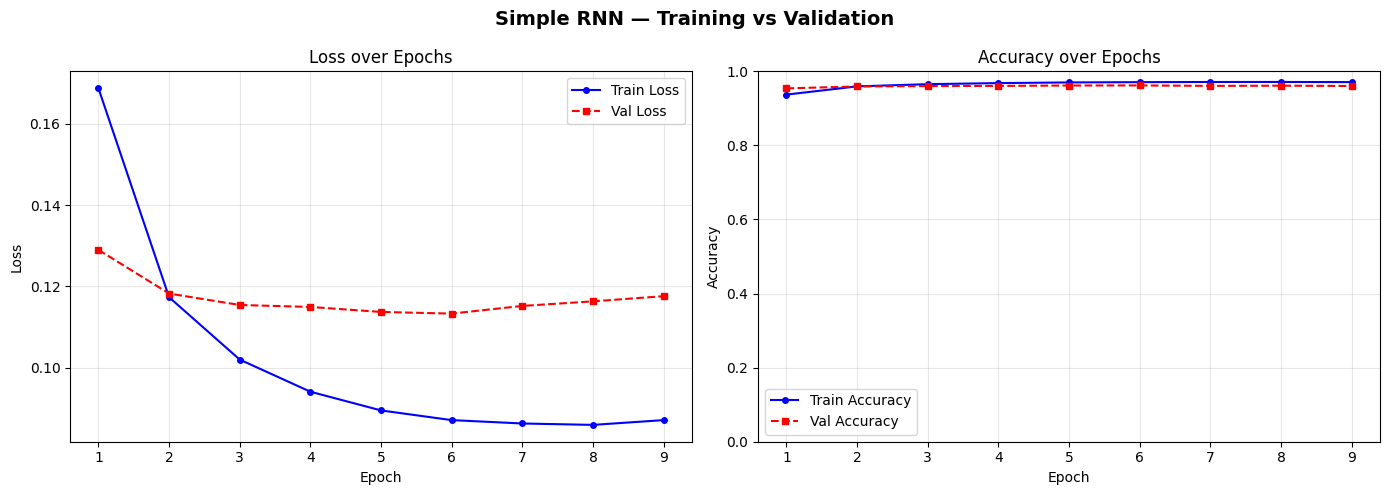

In [39]:
rnn_epochs = range(1, len(rnn_history.history['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Simple RNN — Training vs Validation',
             fontsize=14, fontweight='bold')

# Loss
axes[0].plot(rnn_epochs, rnn_history.history['loss'],
             'b-o', markersize=4, label='Train Loss')
axes[0].plot(rnn_epochs, rnn_history.history['val_loss'],
             'r--s', markersize=4, label='Val Loss')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(rnn_epochs, rnn_history.history['accuracy'],
             'b-o', markersize=4, label='Train Accuracy')
axes[1].plot(rnn_epochs, rnn_history.history['val_accuracy'],
             'r--s', markersize=4, label='Val Accuracy')
axes[1].set_title('Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

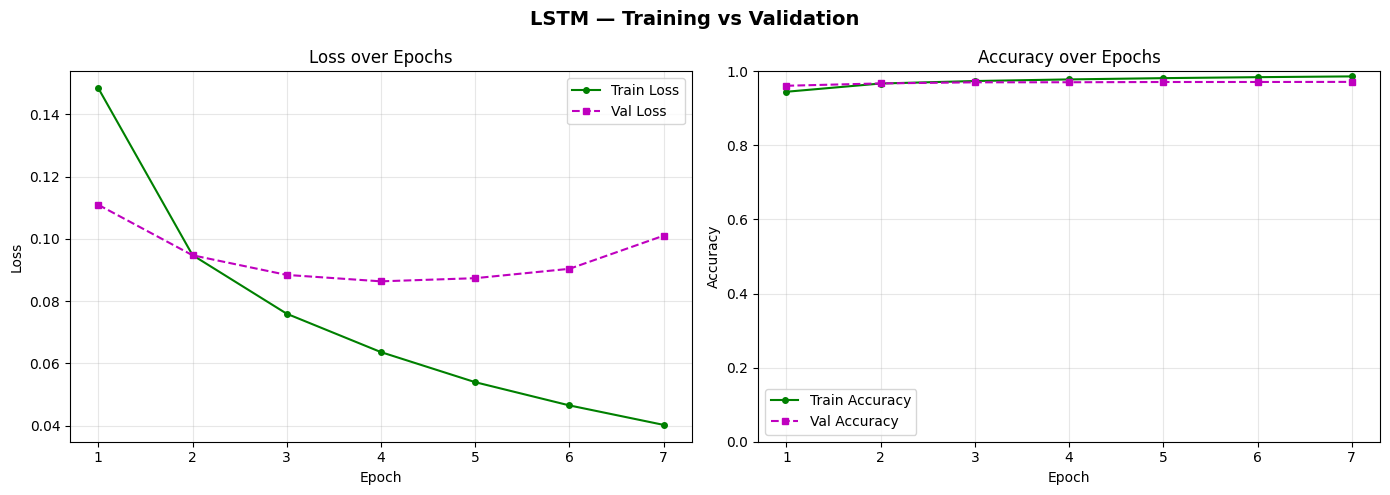

In [40]:
lstm_epochs = range(1, len(lstm_history.history['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('LSTM — Training vs Validation',
             fontsize=14, fontweight='bold')

# Loss
axes[0].plot(lstm_epochs, lstm_history.history['loss'],
             'g-o', markersize=4, label='Train Loss')
axes[0].plot(lstm_epochs, lstm_history.history['val_loss'],
             'm--s', markersize=4, label='Val Loss')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(lstm_epochs, lstm_history.history['accuracy'],
             'g-o', markersize=4, label='Train Accuracy')
axes[1].plot(lstm_epochs, lstm_history.history['val_accuracy'],
             'm--s', markersize=4, label='Val Accuracy')
axes[1].set_title('Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

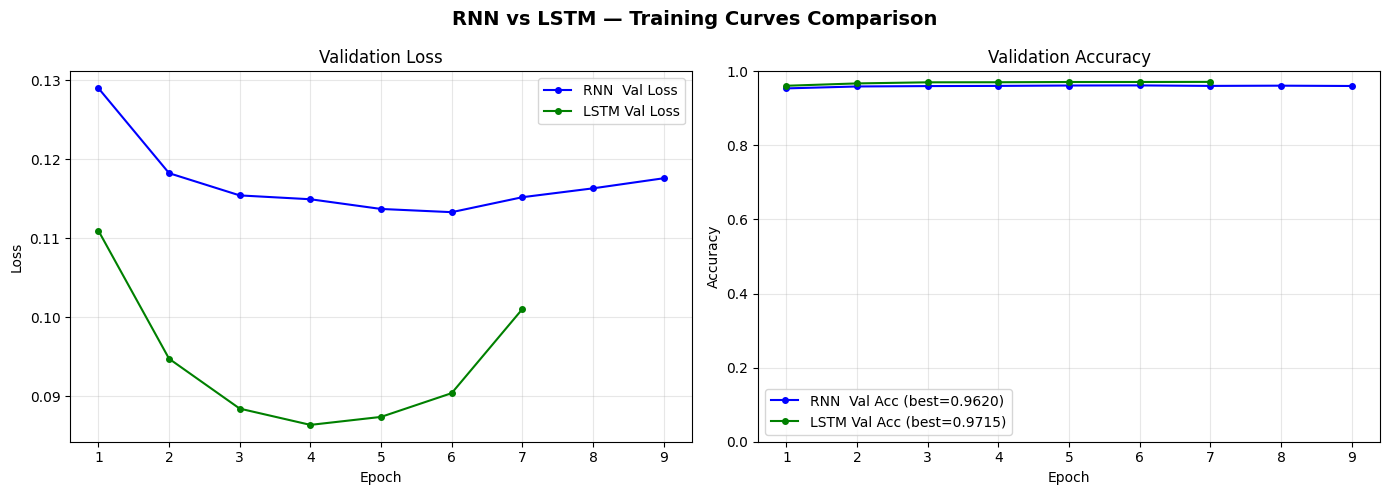

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('RNN vs LSTM — Training Curves Comparison',
             fontsize=14, fontweight='bold')

# Validation Loss comparison
axes[0].plot(rnn_epochs,  rnn_history.history['val_loss'],
             'b-o', markersize=4, label='RNN  Val Loss')
axes[0].plot(lstm_epochs, lstm_history.history['val_loss'],
             'g-o', markersize=4, label='LSTM Val Loss')
axes[0].set_title('Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Validation Accuracy comparison
axes[1].plot(rnn_epochs,  rnn_history.history['val_accuracy'],
             'b-o', markersize=4, label=f'RNN  Val Acc (best={max(rnn_history.history["val_accuracy"]):.4f})')
axes[1].plot(lstm_epochs, lstm_history.history['val_accuracy'],
             'g-o', markersize=4, label=f'LSTM Val Acc (best={max(lstm_history.history["val_accuracy"]):.4f})')
axes[1].set_title('Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

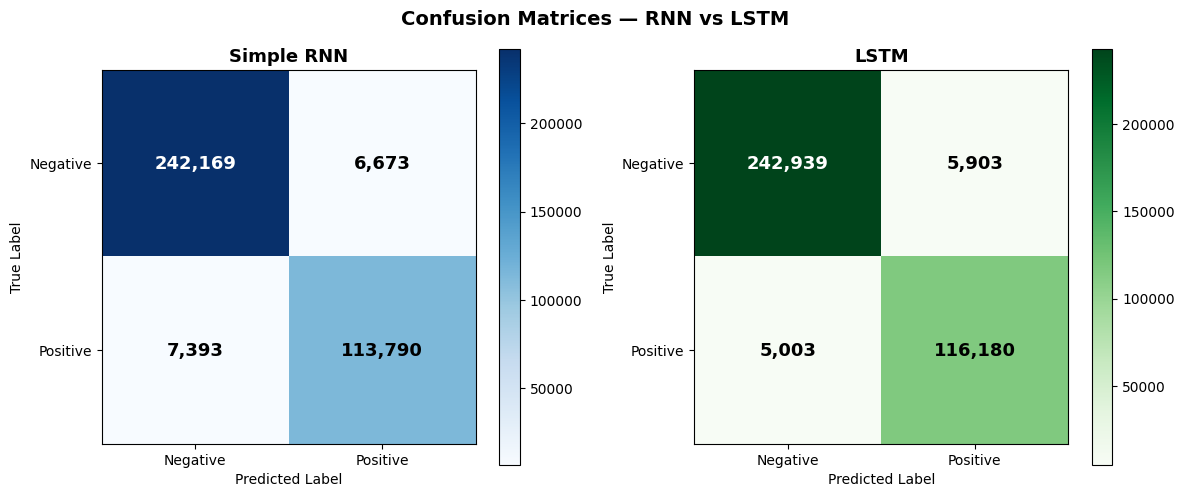

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Confusion Matrices — RNN vs LSTM',
             fontsize=14, fontweight='bold')

for ax, cm, title, cmap in zip(
    axes,
    [rnn_cm, lstm_cm],
    ['Simple RNN', 'LSTM'],
    ['Blues', 'Greens']
):
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.colorbar(im, ax=ax)
    ax.set_title(title, fontsize=13, fontweight='bold')

    # Axis labels
    tick_marks = [0, 1]
    ax.set_xticks(tick_marks)
    ax.set_yticks(tick_marks)
    ax.set_xticklabels(['Negative', 'Positive'])
    ax.set_yticklabels(['Negative', 'Positive'])
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

    # Value annotations inside cells
    thresh = cm.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], ','),
                    ha='center', va='center',
                    fontsize=13, fontweight='bold',
                    color='white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.show()

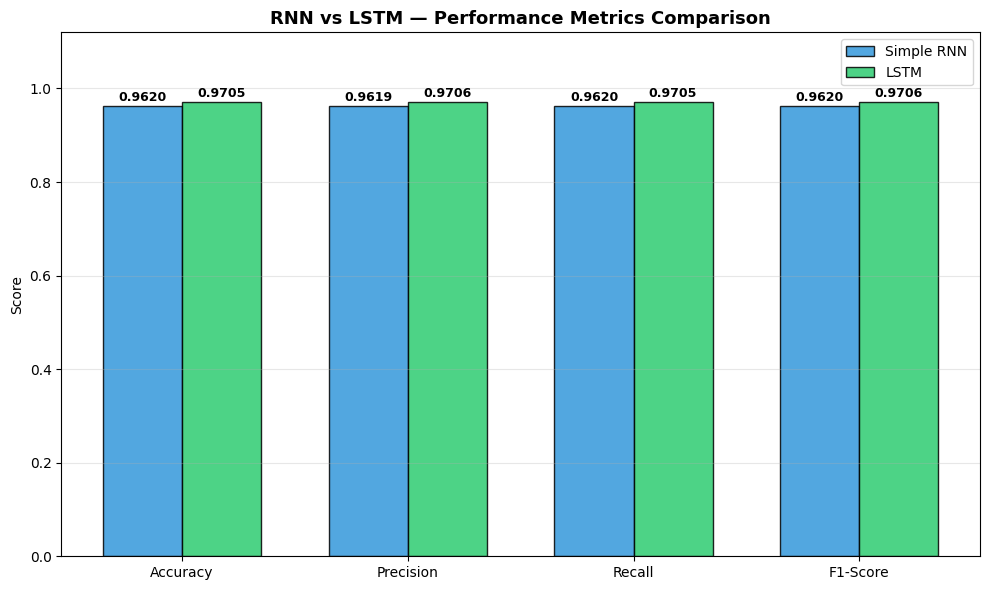

In [43]:
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
rnn_scores  = [rnn_acc,  rnn_precision,  rnn_recall,  rnn_f1]
lstm_scores = [lstm_acc, lstm_precision, lstm_recall, lstm_f1]

x = np.arange(len(metrics_names))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - w/2, rnn_scores,  w,
               label='Simple RNN', color='#3498db',
               edgecolor='black', alpha=0.85)
bars2 = ax.bar(x + w/2, lstm_scores, w,
               label='LSTM',       color='#2ecc71',
               edgecolor='black', alpha=0.85)

# Value labels on top of each bar
for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2,
            h + 0.005, f'{h:.4f}',
            ha='center', va='bottom',
            fontsize=9, fontweight='bold')

ax.set_title('RNN vs LSTM — Performance Metrics Comparison',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

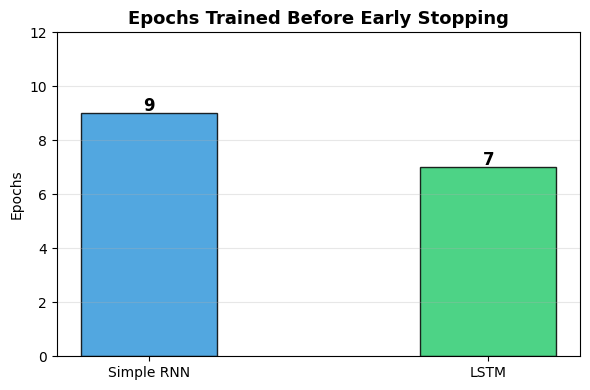

In [58]:
fig, ax = plt.subplots(figsize=(6, 4))

models  = ['Simple RNN', 'LSTM']
epochs_trained = [len(rnn_history.history['loss']),
                  len(lstm_history.history['loss'])]
colors  = ['#3498db', '#2ecc71']

bars = ax.bar(models, epochs_trained, color=colors,
              edgecolor='black', alpha=0.85, width=0.4)
for bar, ep in zip(bars, epochs_trained):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.1, str(ep),
            ha='center', fontsize=12, fontweight='bold')

ax.set_title('Epochs Trained Before Early Stopping',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Epochs')
ax.set_ylim(0, 12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

 GUI for Real-Time Prediction

    • Use Tkinter, Gradio, or Streamlit to create a simple interface.

    • Allow users to input a tweet and get a sentiment prediction.

In [61]:
!pip install gradio -q

In [62]:
import gradio as gr
import numpy as np

def predict_sentiment(tweet, model_name):
    # 1. Preprocess the input tweet
    cleaned_tweet = preprocess_text(tweet)

    if not cleaned_tweet:
        return "N/A", "N/A", "Empty or irrelevant text after cleaning."

    # 2. Tokenize and pad the cleaned text
    sequence = tokenizer.texts_to_sequences([cleaned_tweet])
    padded_sequence = pad_sequences(sequence, maxlen=MAX_LEN, padding='post', truncating='post')

    # 3. Load the appropriate model and make prediction
    model = None
    if model_name == "Simple RNN":
        model = rnn_model
    elif model_name == "LSTM":
        model = lstm_model

    if model is None:
        return "Error", "N/A", "Model not selected or not found."

    prediction = model.predict(padded_sequence, verbose=0)[0][0]

    # 4. Interpret the prediction
    if prediction >= 0.5:
        sentiment = "Positive"
        confidence = f"{prediction * 100:.2f}%"
    else:
        sentiment = "Negative"
        confidence = f"{(1 - prediction) * 100:.2f}%"

    return sentiment, confidence, cleaned_tweet


with gr.Blocks(title="Trump Tweet Sentiment Analyser") as demo:

    gr.Markdown("""
    # 🐦 Tweet Sentiment Analyser
    Enter any tweet below and select a model to predict its sentiment.
    """)

    with gr.Row():
        with gr.Column():
            tweet_input = gr.Textbox(
                label="Enter Tweet",
                placeholder="Type or paste a tweet here...",
                lines=3
            )
            model_choice = gr.Radio(
                choices=["Simple RNN", "LSTM"],
                value="LSTM",
                label="Select Model"
            )
            predict_btn = gr.Button("Predict Sentiment", variant="primary")

        with gr.Column():
            sentiment_out  = gr.Textbox(label="Predicted Sentiment")
            confidence_out = gr.Textbox(label="Confidence Score")
            cleaned_out    = gr.Textbox(label="Cleaned Text (after preprocessing)")

    # ── Example Tweets ───────────────────────────────────────
    gr.Markdown("### 💡 Try these example tweets:")
    gr.Examples(
        examples=[
            ["I love this! Amazing work, truly the best! 🎉",         "LSTM"],
            ["This is a total disaster. Worst decision ever! 😡",      "LSTM"],
            ["Just landed in New York. Great meeting today! 🇺🇸",      "Simple RNN"],
            ["Fake news! The media is lying to everyone.",             "Simple RNN"],
            ["Thank you all for the support! We will make it great!", "LSTM"],
        ],
        inputs=[tweet_input, model_choice]
    )

    # ── Button Click ─────────────────────────────────────────
    predict_btn.click(
        fn=predict_sentiment,
        inputs=[tweet_input, model_choice],
        outputs=[sentiment_out, confidence_out, cleaned_out]
    )

# ── Launch ───────────────────────────────────────────────────
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b7fe79c8a5ed19be3d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


AttributeError: module 'gradio' has no attribute 'blocks'